<a href="https://colab.research.google.com/github/yannn2505/Belajar-OpenCV-ObjectDetection_Pertemuan7/blob/main/7_2_experiment_region_proposal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 7.2 Experiment Region Proposal

⚠️⚠️⚠️ *Please open this notebook in Google Colab* by click below link ⚠️⚠️⚠️<br><br>
<a href="https://colab.research.google.com/github/Muhammad-Yunus/Belajar-OpenCV-ObjectDetection/blob/main/Pertemuan%207/7.2%20experiment_region_proposal.ipynb" target="_blank"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a><br><br><br>
- Click `Connect` button in top right Google Colab notebook,<br>
<img src="https://github.com/Muhammad-Yunus/Belajar-OpenCV-ObjectDetection/blob/main/Pertemuan%207/resource/cl-connect-gpu.png?raw=1" width="250px">
- If connecting process completed, it will turn to something look like this<br>
<img src="https://github.com/Muhammad-Yunus/Belajar-OpenCV-ObjectDetection/blob/main/Pertemuan%207/resource/cl-connect-gpu-success.png?raw=1" width="250px">

- Check GPU connected into Colab environment is active

In [ ]:
!nvidia-smi

'nvidia-smi' is not recognized as an internal or external command,
operable program or batch file.


<br><br><br><br>
#### 7.2.1 <font color="orange">Selective Search</font>
- Implementasi sederhana Selective Search menggunakan OpenCV untuk melakukan segmentasi gambar berdasarkan kemiripan warna.
- Proses ini kemudian menghasilkan kandidat bounding box sebagai hasil dari kontur (contour) pada gambar yang telah disegmentasi, sehingga area yang kemungkinan mengandung objek dapat terdeteksi.
- Dengan metode ini, gambar dipecah menjadi beberapa bagian kecil, kemudian bagian-bagian yang memiliki kemiripan digabungkan hingga membentuk region yang berpotensi sebagai objek.

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

- Load the image

In [ ]:
# Download gambar contoh dari repository
import urllib

url, filename = (
    "https://github.com/Muhammad-Yunus/Belajar-OpenCV-ObjectDetection/raw/main/Pertemuan%207/astronaut.jpg",
    "astronaut.jpg"
)

try:
    # Cara lama (untuk kompatibilitas versi Python tertentu)
    urllib.URLopener().retrieve(url, filename)
except:
    # Cara yang lebih umum digunakan (Python versi baru)
    urllib.request.urlretrieve(url, filename)

# Penjelasan:
# - Kode ini digunakan untuk mengunduh gambar dari internet
# - url berisi alamat file gambar, filename adalah nama file yang akan disimpan
# - try-except digunakan agar kode tetap berjalan di berbagai versi Python
# - Gambar ini nantinya digunakan sebagai input untuk proses object detection / selective search

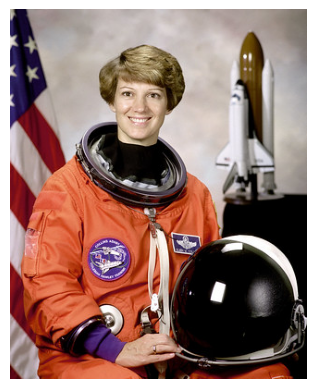

In [ ]:
# Membaca gambar dari file
image = cv2.imread("astronaut.jpg")

# Fungsi untuk menampilkan gambar menggunakan matplotlib
def imshow(image, isBGR=True):
    if isBGR:
        # OpenCV membaca gambar dalam format BGR, sedangkan matplotlib menggunakan RGB
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    plt.imshow(image)   # menampilkan gambar
    plt.axis("off")     # menghilangkan axis agar tampilan lebih bersih

# Menampilkan gambar
imshow(image)

# Penjelasan:
# - cv2.imread() digunakan untuk membaca gambar dari file
# - Fungsi imshow dibuat agar bisa menampilkan gambar dengan benar di matplotlib
# - Konversi BGR → RGB penting agar warna tidak terbalik
# - plt.axis("off") digunakan supaya tampilan lebih rapi tanpa garis koordinat

- Mendefinisikan fungsi untuk <font color="cyan">Color Quantization</font> menggunakan <font color="orange">K-means clustering</font>,
    - Menentukan jumlah <font color="orange">Cluster</font> ($k$),
        - Misalnya, jika ingin membagi data menjadi 3 kelompok, maka nilai $k=3$.
    - Inisialisasi <font color="orange">Centroid</font>,
        - Menempatkan secara acak $k$ titik (disebut <font color="orange">centroid</font>) pada ruang data.
    - Memperbarui Centroid,
        - Untuk setiap cluster, dihitung <font color="orange">rata-rata</font> dari semua data yang termasuk dalam cluster tersebut.
        - Nilai rata-rata ini menjadi <font color="orange">centroid baru</font>.
    - <font color="orange">Mengulangi</font> hingga stabil,
        - Proses pengelompokan dan pembaruan centroid dilakukan berulang hingga posisi centroid <font color="orange">tidak berubah lagi</font> atau perubahan sangat kecil.
        - Hal ini menandakan setiap data sudah berada pada cluster yang paling sesuai.<br><br>
        <img src="https://github.com/Muhammad-Yunus/Belajar-OpenCV-ObjectDetection/blob/main/Pertemuan%207/resource/K-Means.gif?raw=1" width="900px"><br>
    - Gambar di atas menunjukkan proses K-Means secara iteratif, di mana titik-titik data awalnya tersebar, kemudian secara bertahap dikelompokkan ke centroid terdekat, dan posisi centroid terus diperbarui hingga terbentuk kelompok yang stabil.
- Dalam konteks <font color="cyan">Color Quantization</font>, metode ini digunakan untuk mengurangi jumlah variasi warna pada gambar dengan mengelompokkan warna-warna yang mirip, sehingga mempermudah proses segmentasi pada tahap berikutnya seperti selective search.

- Mengimplementasikan <font color="orange">K-Means Clustering</font> menggunakan OpenCV `cv2.kmeans()`,
    ```
    retval, bestLabels, centers = cv2.kmeans(data, K, bestLabels, criteria, attempts, flags)
    ```
    - di mana :
        - `K` adalah jumlah cluster yang ingin dibentuk dari data.
        - `bestLabels` adalah array yang menyimpan indeks cluster untuk setiap data (menunjukkan data masuk ke cluster mana).
        - `criteria` adalah kriteria berhenti algoritma, bisa berdasarkan jumlah iterasi maksimum atau tingkat akurasi tertentu.
        - `attempts` menentukan berapa kali algoritma dijalankan dengan inisialisasi centroid yang berbeda untuk mendapatkan hasil terbaik.
        - `flags` digunakan untuk menentukan metode inisialisasi centroid, dengan beberapa pilihan:
            - cv2.KMEANS_RANDOM_CENTERS     = 0 (centroid dipilih secara acak),
            - cv2.KMEANS_PP_CENTERS         = 2 (menggunakan metode K-Means++ untuk hasil lebih stabil),
            - cv2.KMEANS_USE_INITIAL_LABELS = 1 (menggunakan label awal yang sudah diberikan).
    - Fungsi ini akan mengelompokkan data ke dalam beberapa cluster berdasarkan kemiripan, dan menghasilkan pusat cluster (centroid) serta label untuk setiap data.

In [ ]:
def color_quantization(image, k=5):
    # Konversi gambar dari BGR ke Lab (lebih baik untuk clustering warna)
    image_lab = cv2.cvtColor(image, cv2.COLOR_BGR2Lab)

    # Ubah gambar menjadi array 2D (setiap pixel jadi 1 baris)
    pixel_values = image_lab.reshape((-1, 3))
    pixel_values = np.float32(pixel_values)

    # Menentukan kriteria berhenti (maks 200 iterasi atau perubahan kecil)
    criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 200, 0.2)

    # Terapkan K-Means clustering
    _, labels, centers = cv2.kmeans(
        pixel_values,
        k,
        None,
        criteria,
        15,
        cv2.KMEANS_RANDOM_CENTERS
    )

    # Ubah centroid ke integer (warna valid)
    centers = np.uint8(centers)

    # Ganti setiap pixel dengan warna centroid dari cluster-nya
    quantized_image = centers[labels.flatten()]

    # Kembalikan ke bentuk gambar semula
    quantized_image = quantized_image.reshape(image.shape)

    # Konversi kembali dari Lab ke BGR
    return cv2.cvtColor(quantized_image, cv2.COLOR_Lab2BGR)

# Penjelasan:
# - Fungsi ini digunakan untuk mengurangi jumlah variasi warna dalam gambar
# - K-Means mengelompokkan warna yang mirip menjadi k kelompok
# - Setiap pixel diganti dengan warna pusat cluster (centroid)
# - Hasilnya gambar jadi lebih sederhana (warna lebih sedikit)

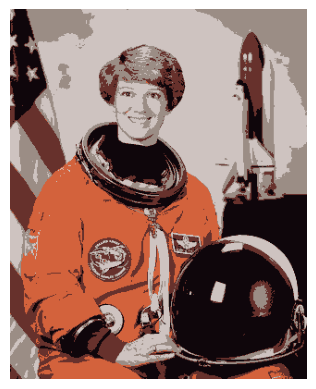

In [ ]:
# generate segmented image using k=5
segmented_image = color_quantization(image, k=5)

# show segmented image
imshow(segmented_image)

- Mendefinisikan fungsi untuk <font color="cyan">Extract Bounding Box</font> dari hasil segmentasi gambar
    - Mengubah `segmented_image` menjadi citra biner (hitam-putih) menggunakan metode Otsu Thresholding (`cv2.THRESH_OTSU`), sehingga objek dan background dapat dipisahkan dengan lebih jelas,
    - Mencari kontur pada citra biner menggunakan `cv2.findContours()` untuk mendeteksi bentuk atau area objek,
    - Menentukan <font color="orange">Bounding Box</font> dari setiap kontur menggunakan `cv2.boundingRect()` sehingga diperoleh koordinat kotak yang membungkus objek,
    - Melakukan penyaringan berdasarkan ukuran kotak ($w*h$ >= $min size$) untuk menghilangkan objek kecil atau noise yang tidak relevan.
    - Dengan proses ini, hanya area yang berpotensi sebagai objek yang akan dipertahankan sebagai kandidat region proposal.

In [ ]:
def get_bounding_boxes(segmented_image, min_size=200):
    # Ubah gambar ke grayscale
    gray = cv2.cvtColor(segmented_image, cv2.COLOR_BGR2GRAY)

    # Terapkan Otsu Thresholding untuk mendapatkan gambar biner
    _, binary = cv2.threshold(
        gray,
        0,
        255,
        cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )

    # Mencari kontur pada gambar biner
    contours, _ = cv2.findContours(
        binary,
        cv2.RETR_LIST,
        cv2.CHAIN_APPROX_SIMPLE
    )

    # Membuat bounding box untuk kontur yang cukup besar
    boxes = []
    for contour in contours:
        x, y, w, h = cv2.boundingRect(contour)

        # Filter berdasarkan ukuran (hilangkan noise kecil)
        if w * h >= min_size:
            boxes.append((x, y, w, h))

    return boxes

# Penjelasan:
# - Gambar segmentasi diubah ke grayscale lalu ke biner (hitam-putih)
# - Kontur digunakan untuk mendeteksi area objek
# - Setiap kontur dibungkus dengan bounding box
# - Bounding box kecil dihapus agar hasil lebih bersih

In [ ]:
# Mengambil bounding box dari hasil segmentasi
boxes = get_bounding_boxes(segmented_image, min_size=500)

# Menampilkan hasil bounding box
print(boxes)

# Penjelasan:
# - Fungsi get_bounding_boxes akan mengembalikan daftar koordinat bounding box
# - Format setiap box: (x, y, w, h)
#     x, y = posisi titik kiri atas
#     w, h = lebar dan tinggi box
# - min_size=500 digunakan untuk menyaring objek kecil (noise)
# - print(boxes) digunakan untuk melihat hasil deteksi dalam bentuk data

[(243, 386, 57, 14), (212, 370, 95, 14), (239, 346, 72, 33), (0, 329, 54, 71), (133, 320, 30, 37), (90, 283, 60, 41), (67, 276, 16, 32), (96, 256, 37, 40), (83, 246, 42, 34), (129, 245, 17, 46), (69, 121, 124, 113), (95, 67, 24, 38), (142, 52, 48, 60), (244, 24, 32, 126), (0, 0, 321, 400)]


- <font color="cyan">Draw Bounding Box</font> on original image using `cv2.rectangle`

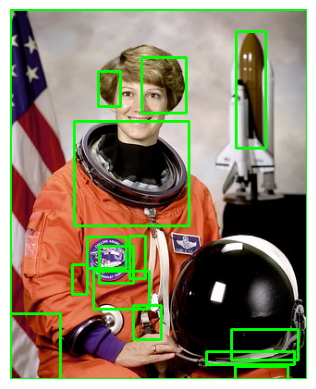

In [ ]:
# Menentukan jumlah maksimal bounding box yang akan ditampilkan
MAX_BOX = 100

# Salin gambar asli agar tidak merusak image original
image_with_boxes = image.copy()

# Gambar bounding box pada image
for (x, y, w, h) in boxes[:MAX_BOX]:
    cv2.rectangle(
        image_with_boxes,
        (x, y),                 # titik kiri atas
        (x + w, y + h),         # titik kanan bawah
        (0, 255, 0),            # warna hijau
        2                       # ketebalan garis
    )

# Tampilkan hasil
imshow(image_with_boxes)

# Penjelasan:
# - boxes berisi koordinat bounding box hasil segmentasi
# - image.copy() digunakan agar gambar asli tidak berubah
# - cv2.rectangle() menggambar kotak di sekitar objek
# - boxes[:MAX_BOX] membatasi jumlah box agar tidak terlalu ramai

_______
<br><br><br><br>
### 7.2.2 <font color="orange">RPN</font> (Region Proposal Network)
- Pada bagian ini kita akan mencoba mengimplementasikan <font color="orange">RPN (Region Proposal Network)</font> menggunakan PyTorch berdasarkan diagram berikut,<br>
<img src="https://github.com/Muhammad-Yunus/Belajar-OpenCV-ObjectDetection/blob/main/Pertemuan%207/resource/RPN2.png?raw=1" width="95%">
- Diagram tersebut menunjukkan alur kerja RPN, dimulai dari feature map hasil CNN yang kemudian diproses menggunakan sliding window kecil (biasanya kernel 3x3) untuk menghasilkan banyak kandidat <font color="orange">anchor boxes</font> di setiap posisi.
- Setiap anchor box memiliki variasi ukuran dan rasio, sehingga dapat mencakup berbagai bentuk objek dalam gambar.
- Selanjutnya, RPN menghasilkan dua output utama:
    - <font color="orange">Objectness Score</font>, yaitu nilai yang menunjukkan apakah sebuah area mengandung objek atau hanya background,
    - <font color="orange">Bounding Box Regression</font>, yaitu penyesuaian posisi anchor box agar lebih sesuai dengan objek sebenarnya.
- Setelah itu, dilakukan proses <font color="orange">NMS (Non-Maximum Suppression)</font> untuk menghapus bounding box yang tumpang tindih dan hanya menyisakan kandidat terbaik.
- Dengan demikian, RPN berfungsi untuk menghasilkan region proposal secara otomatis dan lebih cepat dibandingkan metode sebelumnya seperti selective search.

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
from torchvision import transforms

- Memuat model <font color="orange">ResNet-34</font> yang sudah dilatih (pretrained) dari torch.hub
    - Model pretrained berarti model yang sudah dilatih sebelumnya pada dataset besar (seperti ImageNet), sehingga sudah memiliki kemampuan mengenali fitur dasar seperti tepi, tekstur, dan bentuk.
    - Dengan menggunakan model pretrained, kita tidak perlu melatih model dari awal, sehingga lebih cepat dan efisien.
    - Dalam konteks RPN, ResNet-34 digunakan sebagai <font color="orange">feature extractor</font> untuk menghasilkan feature map yang akan digunakan dalam proses region proposal.

In [ ]:
# Load model ResNet-34 pretrained dari torch hub
backbone = torch.hub.load(
    'pytorch/vision:v0.10.0',
    'resnet34',
    pretrained=True
)

# Menghapus layer fully connected (bagian klasifikasi)
# dan hanya menyisakan layer convolution (feature extractor)
backbone = nn.Sequential(*list(backbone.children())[:-2])

# Set model ke mode evaluasi (tidak training)
backbone.eval()

# Penjelasan:
# - ResNet-34 digunakan sebagai backbone untuk mengekstrak fitur dari gambar
# - pretrained=True artinya model sudah dilatih sebelumnya (misalnya di ImageNet)
# - children()[:-2] digunakan untuk membuang layer akhir (FC + pooling)
# - Hasilnya adalah feature map, bukan prediksi klasifikasi
# - eval() digunakan agar model berjalan dalam mode inference (tidak update parameter)

Using cache found in /root/.cache/torch/hub/pytorch_vision_v0.10.0


Sequential(
  (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU(inplace=True)
  (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (4): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Con

- Load Image Sample

In [ ]:
# Load an example image and preprocess it
image_path = 'astronaut.jpg'  # path gambar yang akan digunakan
image = cv2.imread(image_path)  # membaca gambar (format BGR dari OpenCV)

H, W = 224, 224  # ukuran standar input ResNet
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)  # ubah BGR → RGB agar sesuai model
image = cv2.resize(image, (W, H))  # resize gambar ke 224x224

# Convert image to tensor and normalize as required by ResNet
input_tensor = torch.tensor(image).float().permute(2, 0, 1).unsqueeze(0)
# penjelasan:
# - torch.tensor(image) → ubah gambar ke tensor
# - .float() → ubah tipe data ke float
# - .permute(2,0,1) → ubah format (H,W,C) jadi (C,H,W)
# - .unsqueeze(0) → tambah dimensi batch jadi (1,C,H,W)

input_tensor = input_tensor / 255.0
# normalisasi pixel dari 0-255 → 0-1

input_tensor = transforms.Normalize(
    mean=[0.485, 0.456, 0.406],
    std=[0.229, 0.224, 0.225]
)(input_tensor)
# normalisasi sesuai standar ImageNet (biar cocok dengan model pretrained ResNet)

- Forward pass image tensor to CNN Backbone (Resnet-34)

In [ ]:
# Generate feature map menggunakan ResNet-34
with torch.no_grad():  # menonaktifkan perhitungan gradien (lebih cepat & hemat memori)
    feature_map = backbone(input_tensor)  # input gambar diproses oleh ResNet (feature extractor)

# Penjelasan:
# - backbone adalah ResNet-34 tanpa layer klasifikasi (hanya convolution)
# - input_tensor adalah gambar yang sudah dipreprocess
# - output berupa feature_map (representasi fitur dari gambar)
# - torch.no_grad() digunakan karena ini hanya inferensi, bukan training

<br><br><br><br>
- <font color="orange">RPN Head</font> Implementation in PyTorch
    - <font color="orange">RPN Head</font> biasanya terdiri dari <font color="orange">layer konvolusi 3x3</font> yang digunakan untuk melakukan scanning pada feature map dan mengekstrak informasi lokal di setiap posisi.
    - Dari hasil tersebut, terdapat dua cabang output utama:
        - Cabang klasifikasi (object vs background) menggunakan <font color="orange">layer konvolusi 1x1</font>, yang berfungsi untuk menentukan apakah suatu area mengandung objek atau hanya background.
        - Cabang regresi (perbaikan bounding box) menggunakan <font color="orange">layer konvolusi 1x1</font>, yang berfungsi untuk menyesuaikan posisi dan ukuran bounding box agar lebih akurat.
            <img src="https://github.com/Muhammad-Yunus/Belajar-OpenCV-ObjectDetection/blob/main/Pertemuan%207/resource/RPN.png?raw=1" width="700px">
    - Gambar di atas menunjukkan bahwa feature map terlebih dahulu diproses dengan convolution 3x3, kemudian hasilnya dibagi menjadi dua cabang, yaitu untuk klasifikasi (objectness score) dan regresi bounding box.
    - Dengan struktur ini, RPN dapat secara langsung menghasilkan kandidat region proposal secara efisien dalam satu proses.

In [ ]:
class SimpleRPNHead(nn.Module):
    def __init__(self, in_channels=512, num_anchors=9):
        super(SimpleRPNHead, self).__init__()

        # Layer konvolusi 3x3 untuk membaca feature map (sliding window)
        self.conv = nn.Conv2d(in_channels, 512, kernel_size=3, padding=1)

        # Layer klasifikasi (object / background)
        # Setiap anchor menghasilkan 2 nilai (object vs background)
        self.cls_score = nn.Conv2d(512, num_anchors * 2, kernel_size=1)

        # Layer regresi bounding box
        # Setiap anchor menghasilkan 4 nilai (dx, dy, dw, dh)
        self.bbox_delta = nn.Conv2d(512, num_anchors * 4, kernel_size=1)

        # Inisialisasi bobot
        self._init_weights()

    def _init_weights(self):
        for layer in [self.conv, self.cls_score, self.bbox_delta]:
            # Bobot diinisialisasi dengan distribusi normal (biar stabil di awal)
            nn.init.normal_(layer.weight, std=0.01)
            nn.init.constant_(layer.bias, 0)

    def forward(self, x):
        # Feature map diproses dengan conv 3x3 + aktivasi ReLU
        x = F.relu(self.conv(x))

        # Output klasifikasi: menentukan apakah ada objek atau tidak
        cls_score = self.cls_score(x)

        # Output regresi: memperbaiki posisi bounding box
        bbox_delta = self.bbox_delta(x)

        # ================= RESHAPE OUTPUT =================

        # cls_score awal: [batch, num_anchors*2, H, W]
        # diubah jadi: [batch, jumlah_anchor_total, 2]
        cls_score = cls_score.permute(0, 2, 3, 1).contiguous()
        cls_score = cls_score.view(cls_score.shape[0], -1, 2)

        # bbox_delta awal: [batch, num_anchors*4, H, W]
        # diubah jadi: [batch, jumlah_anchor_total, 4]
        bbox_delta = bbox_delta.permute(0, 2, 3, 1).contiguous()
        bbox_delta = bbox_delta.view(bbox_delta.shape[0], -1, 4)

        return cls_score, bbox_delta

# Penjelasan singkat:
# - Input: feature map dari backbone (ResNet)
# - Conv 3x3: ekstraksi fitur lokal
# - cls_score: prediksi ada objek atau tidak
# - bbox_delta: perbaikan posisi bounding box
# - Output sudah diubah bentuknya agar mudah diproses selanjutnya

- jadi RPN Head menerima feature map, kemudian diproses dengan convolution 3x3 untuk mengekstrak fitur lokal. Setelah itu, terdapat dua output, yaitu klasifikasi untuk menentukan apakah ada objek dan regresi untuk memperbaiki posisi bounding box. Output kemudian diubah bentuknya agar mudah digunakan pada tahap selanjutnya.


- Inisialisasi <font color="orange">RPN Head</font>
    - `num_anchors=9` adalah jumlah anchor yang digunakan dengan variasi <font color="orange">scale</font> (ukuran) dan <font color="orange">aspect ratio</font> (rasio bentuk).
    - Anchor ini merupakan bounding box awal yang diletakkan di setiap posisi pada feature map, sehingga memungkinkan model mendeteksi objek dengan berbagai ukuran dan bentuk.
    - Dengan kombinasi beberapa scale dan aspect ratio, model dapat menangkap objek kecil, sedang, hingga besar secara lebih fleksibel.

In [ ]:
# Inisialisasi RPN Head dengan jumlah channel sesuai output ResNet (512)
rpn_head = SimpleRPNHead(in_channels=512, num_anchors=9)

# Penjelasan:
# - in_channels=512 karena output feature map dari ResNet-34 memiliki 512 channel
# - num_anchors=9 artinya setiap posisi pada feature map memiliki 9 anchor box
# - Setiap anchor mewakili variasi ukuran (scale) dan bentuk (aspect ratio)
# - RPN akan menggunakan anchor ini untuk memprediksi:
#     1. Apakah ada objek (objectness)
#     2. Bagaimana posisi bounding box (regresi)

- Melakukan <font color="orange">forward pass</font> pada feature map dari backbone ke <font color="orange">RPN</font>
    - Feature map yang dihasilkan dari backbone (ResNet-34) digunakan sebagai input untuk RPN.
    - RPN akan memproses feature map tersebut untuk menghasilkan dua output utama:
        - <font color="orange">Objectness Score</font>, yaitu menentukan apakah suatu area mengandung objek atau hanya background.
        - <font color="orange">Bounding Box Regression</font>, yaitu memperbaiki posisi dan ukuran anchor box agar sesuai dengan objek.
    - Proses ini dilakukan dalam satu tahap sehingga RPN dapat secara langsung menghasilkan kandidat region proposal dari feature map.

In [ ]:
# Jalankan feature map ke RPN untuk mendapatkan prediksi
cls_scores, bbox_deltas = rpn_head(feature_map)

# Tampilkan bentuk (shape) dari setiap output
print(f"Feature map shape: {feature_map.shape}")
print(f"Class scores shape: {cls_scores.shape}")
print(f"Bbox deltas shape: {bbox_deltas.shape}")

# Penjelasan:
# - feature_map adalah output dari backbone (ResNet)
#   biasanya berbentuk: [batch, channel, height, width]
#
# - cls_scores adalah output klasifikasi dari RPN
#   bentuk: [batch, jumlah_anchor_total, 2]
#   → 2 = object / background
#
# - bbox_deltas adalah output regresi bounding box
#   bentuk: [batch, jumlah_anchor_total, 4]
#   → 4 = (dx, dy, dw, dh) untuk memperbaiki posisi anchor
#
# - jumlah_anchor_total = H × W × num_anchors

Feature map shape: torch.Size([1, 512, 7, 7])
Class scores shape: torch.Size([1, 441, 2])
Bbox deltas shape: torch.Size([1, 441, 4])


<br><br><br><br>
- <font color="orange">Implementasi Anchor Box Generation</font>
    - Mendefinisikan anchor box dengan berbagai <font color="orange">scale</font> (ukuran) dan <font color="orange">aspect ratio</font> (rasio bentuk) pada setiap posisi di feature map.<br>
    <img src="https://github.com/Muhammad-Yunus/Belajar-OpenCV-ObjectDetection/blob/main/Pertemuan%207/resource/anchor-box-generation.png?raw=1" width="95%">
    - Gambar di atas menunjukkan bahwa pada setiap titik di feature map, dibuat beberapa anchor box dengan ukuran dan bentuk yang berbeda.
    - Anchor box ini berfungsi sebagai bounding box awal yang akan digunakan sebagai kandidat lokasi objek.
    - Variasi <font color="orange">scale</font> memungkinkan model mendeteksi objek kecil, sedang, hingga besar, sedangkan variasi <font color="orange">aspect ratio</font> memungkinkan deteksi objek dengan bentuk yang berbeda (misalnya tinggi, lebar, atau persegi).
    - Dengan adanya banyak anchor box di setiap posisi, model memiliki peluang lebih besar untuk mencocokkan objek yang ada di dalam gambar.

In [ ]:
class SimpleAnchorGenerator:
    def __init__(self, sizes=[32, 64, 128], aspect_ratios=[0.5, 1.0, 2.0]):
        self.sizes = sizes                  # ukuran anchor (kecil, sedang, besar)
        self.aspect_ratios = aspect_ratios  # rasio bentuk (tinggi, kotak, lebar)

    def generate_anchors(self, grid_size, stride):
        anchors = []
        for size in self.sizes:
            for aspect_ratio in self.aspect_ratios:
                # Hitung tinggi & lebar anchor berdasarkan ratio
                anchor_height = size / np.sqrt(aspect_ratio)
                anchor_width = size * np.sqrt(aspect_ratio)

                # Loop setiap posisi pada feature map (grid)
                for y in range(grid_size[0]):
                    for x in range(grid_size[1]):

                        # Hitung titik tengah anchor di koordinat gambar asli
                        center_x = (x + 0.5) * stride
                        center_y = (y + 0.5) * stride

                        # Konversi ke format bounding box (x_min, y_min, x_max, y_max)
                        x_min = center_x - 0.5 * anchor_width
                        y_min = center_y - 0.5 * anchor_height
                        x_max = center_x + 0.5 * anchor_width
                        y_max = center_y + 0.5 * anchor_height

                        anchors.append([x_min, y_min, x_max, y_max])

        return torch.tensor(anchors)

# Penjelasan:
# - sizes → variasi ukuran anchor (deteksi objek kecil sampai besar)
# - aspect_ratios → variasi bentuk (tinggi, lebar, persegi)
# - grid_size → ukuran feature map (misalnya 7x7)
# - stride → jarak antara grid ke gambar asli
# - Setiap titik grid menghasilkan banyak anchor (size × ratio)
# - Output berupa daftar bounding box dalam format (x_min, y_min, x_max, y_max)

In [ ]:
# Inisialisasi anchor generator
anchor_generator = SimpleAnchorGenerator(
    sizes=[8, 16, 32],        # ukuran anchor (kecil → besar)
    aspect_ratios=[1.0]       # rasio 1:1 (persegi)
)

# Ukuran feature map dari ResNet-34 (misalnya 7x7)
grid_size = (7, 7)

# Menghitung stride (jarak antar grid ke gambar asli)
stride = W // grid_size[0]

# Generate anchor
anchors = anchor_generator.generate_anchors(grid_size, stride)

# Menampilkan shape hasil anchor
print(anchors.shape)  # format: (jumlah_anchor, 4)

# Penjelasan:
# - sizes=[8,16,32] → 3 ukuran anchor
# - aspect_ratios=[1.0] → hanya bentuk persegi
# - grid_size=7x7 → ada 49 titik di feature map
# - total anchor = 7 × 7 × 3 × 1 = 147 anchor
# - setiap anchor punya format (x_min, y_min, x_max, y_max)

torch.Size([147, 4])


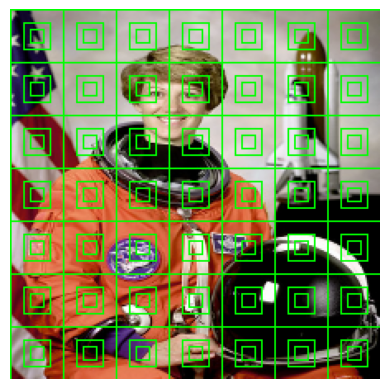

In [ ]:
# Gambar anchor box pada gambar asli
image_with_boxes = image.copy()  # salin gambar agar tidak merusak aslinya

for (x0, y0, x1, y1) in anchors:
    # Ubah koordinat ke integer (karena pixel harus bilangan bulat)
    x0, y0, x1, y1 = int(x0), int(y0), int(x1), int(y1)

    # Gambar kotak anchor
    cv2.rectangle(
        image_with_boxes,
        (x0, y0),        # titik kiri atas
        (x1, y1),        # titik kanan bawah
        (0, 255, 0),     # warna hijau
        1                # ketebalan garis
    )

# Tampilkan hasil
imshow(image_with_boxes, isBGR=False)

# Penjelasan:
# - anchors berisi daftar bounding box awal (anchor box)
# - image.copy() agar gambar asli tidak berubah
# - cv2.rectangle() digunakan untuk menggambar anchor box
# - isBGR=False karena gambar sudah dalam format RGB

- Menerapkan <font color="orange">Region Proposal Network (RPN)</font><br>
<img src="https://github.com/Muhammad-Yunus/Belajar-OpenCV-ObjectDetection/blob/main/Pertemuan%207/resource/Region-Proposal-network.png?raw=1" width="95%">
- Gambar di atas menunjukkan alur lengkap penggunaan RPN dalam object detection, dimulai dari gambar input yang diproses oleh backbone (CNN) untuk menghasilkan <font color="orange">feature map</font>.
- Feature map tersebut kemudian digunakan oleh <font color="orange">RPN</font> untuk menghasilkan banyak <font color="orange">anchor box</font> di setiap posisi.
- Setiap anchor akan diproses untuk menghasilkan:
    - <font color="orange">Objectness Score</font>, yaitu menentukan apakah area tersebut mengandung objek atau hanya background,
    - <font color="orange">Bounding Box Regression</font>, yaitu memperbaiki posisi anchor agar sesuai dengan objek sebenarnya.
- Selanjutnya dilakukan proses <font color="orange">NMS (Non-Maximum Suppression)</font> untuk menghilangkan bounding box yang tumpang tindih dan hanya menyisakan kandidat terbaik.
- Hasil akhir dari proses ini adalah <font color="orange">region proposal</font>, yaitu kumpulan bounding box yang paling mungkin berisi objek dan akan digunakan pada tahap deteksi selanjutnya.

In [ ]:
class SimpleRegionProposalNetwork(nn.Module):
    def __init__(self, anchor_generator, rpn_head, nms_thresh=0.4, objectness_thresh=0.3, num_proposals=1000):
        super(SimpleRegionProposalNetwork, self).__init__()

        self.anchor_generator = anchor_generator
        # fungsi untuk membuat anchor box (bounding box awal)

        self.rpn_head = rpn_head
        # model RPN head untuk prediksi objectness & bbox

        self.nms_thresh = nms_thresh
        # threshold untuk NMS (semakin kecil → makin ketat buang box overlap)

        self.objectness_thresh = objectness_thresh
        # threshold untuk menentukan apakah anchor dianggap mengandung objek

        self.num_proposals = num_proposals
        # jumlah maksimal region proposal yang diambil

    def forward(self, feature_map, image_size):

        # ================= 1. GENERATE ANCHOR =================
        grid_size = feature_map.shape[-2:]
        # ambil ukuran feature map (H, W)

        stride = image_size[0] // grid_size[0]
        # hitung jarak tiap grid ke gambar asli

        anchors = self.anchor_generator.generate_anchors(grid_size, stride)
        # buat anchor box di setiap titik feature map

        # ================= 2. RPN HEAD =================
        objectness, bbox_deltas = self.rpn_head(feature_map)
        # objectness → apakah ada objek
        # bbox_deltas → perbaikan posisi bounding box

        # ================= 3. REFINE BOX =================
        proposals = self.refine_box(anchors, bbox_deltas)
        # ubah anchor menjadi bounding box yang lebih akurat

        # ================= 4. NMS FILTER =================
        batch_size = feature_map.shape[0]
        final_proposals = []

        for i in range(batch_size):

            # ambil hanya box dengan score tinggi
            keep = objectness[i, :, 0] > self.objectness_thresh
            scores = objectness[i, keep, 0]
            proposals_for_image = proposals[i][keep]

            # lakukan NMS untuk buang box yang tumpang tindih
            keep_indices = self.nms(proposals_for_image, scores, self.nms_thresh)
            proposals_after_nms = proposals_for_image[keep_indices]

            # ambil top N proposal saja
            final_proposals.append(proposals_after_nms[:self.num_proposals])

        return final_proposals


    def refine_box(self, anchors, deltas):
        # ================= KONVERSI ANCHOR =================
        anchors = anchors.unsqueeze(0)
        # tambah dimensi batch

        widths = anchors[:, :, 2] - anchors[:, :, 0]
        heights = anchors[:, :, 3] - anchors[:, :, 1]

        ctr_x = anchors[:, :, 0] + 0.5 * widths
        ctr_y = anchors[:, :, 1] + 0.5 * heights
        # hitung titik tengah anchor

        dx = deltas[..., 0]
        dy = deltas[..., 1]
        dw = deltas[..., 2]
        dh = deltas[..., 3]
        # ambil nilai offset dari RPN

        # ================= HITUNG POSISI BARU =================
        pred_ctr_x = ctr_x + dx * widths
        pred_ctr_y = ctr_y + dy * heights

        pred_w = torch.exp(dw) * widths
        pred_h = torch.exp(dh) * heights
        # hitung ukuran baru box

        pred_boxes = torch.zeros_like(deltas)

        pred_boxes[..., 0] = pred_ctr_x - 0.5 * pred_w
        pred_boxes[..., 1] = pred_ctr_y - 0.5 * pred_h
        pred_boxes[..., 2] = pred_ctr_x + 0.5 * pred_w
        pred_boxes[..., 3] = pred_ctr_y + 0.5 * pred_h
        # ubah ke format (x_min, y_min, x_max, y_max)

        return pred_boxes


    def nms(self, boxes, scores, iou_threshold):
        # ================= SORT SCORE =================
        keep = []
        indices = scores.argsort(descending=True)
        # urutkan dari score tertinggi

        while indices.numel() > 0:
            current = indices[0]
            keep.append(current)
            # ambil box terbaik

            if indices.numel() == 1:
                break

            # hitung overlap dengan box lain
            ious = self.iou(boxes[current].unsqueeze(0), boxes[indices[1:]])

            # buang box yang overlap terlalu besar
            indices = indices[1:][ious.squeeze(0) <= iou_threshold]

        return torch.tensor(keep, dtype=torch.long, device=boxes.device)


    def iou(self, box1, box2):
        # ================= INTERSECTION =================
        inter_xmin = torch.max(box1[:, None, 0], box2[:, 0])
        inter_ymin = torch.max(box1[:, None, 1], box2[:, 1])
        inter_xmax = torch.min(box1[:, None, 2], box2[:, 2])
        inter_ymax = torch.min(box1[:, None, 3], box2[:, 3])

        inter_area = (inter_xmax - inter_xmin).clamp(min=0) * \
                     (inter_ymax - inter_ymin).clamp(min=0)
        # luas area yang overlap

        # ================= AREA BOX =================
        box1_area = (box1[:, 2] - box1[:, 0]) * (box1[:, 3] - box1[:, 1])
        box2_area = (box2[:, 2] - box2[:, 0]) * (box2[:, 3] - box2[:, 1])

        union_area = box1_area[:, None] + box2_area - inter_area
        # total area gabungan

        return inter_area / union_area
        # IoU = intersection / union


# ================= RINGKASAN =================
# Anchor → kandidat awal
# RPN Head → prediksi objectness + bbox
# refine_box → perbaiki posisi
# NMS → buang overlap
# Output → region proposal terbaik

In [ ]:
# ================= INIT ANCHOR =================
anchor_sizes = [32, 64, 128]
# ukuran anchor (kecil, sedang, besar)

anchor_aspect_ratios = [0.5, 1.0, 2.0]
# rasio bentuk (tinggi, persegi, lebar)

anchor_generator = SimpleAnchorGenerator(
    sizes=anchor_sizes,
    aspect_ratios=anchor_aspect_ratios
)
# membuat generator anchor berdasarkan ukuran & rasio


# ================= INIT RPN HEAD =================
rpn_head = SimpleRPNHead(
    in_channels=512,
    num_anchors=len(anchor_sizes) * len(anchor_aspect_ratios)
)
# in_channels=512 → dari output ResNet
# num_anchors = 3 × 3 = 9 anchor per titik


# ================= INIT RPN =================
rpn = SimpleRegionProposalNetwork(
    anchor_generator,
    rpn_head,
    nms_thresh=0.8,
    objectness_thresh=0.3
)
# nms_thresh=0.8 → toleransi overlap cukup besar
# objectness_thresh=0.3 → threshold deteksi objek


# ================= RUN RPN =================
proposals = rpn(feature_map, (W, H))
# feature_map → dari backbone (ResNet)
# (W, H) → ukuran gambar asli


# ================= OUTPUT =================
print([p.shape for p in proposals])
# menampilkan jumlah proposal untuk tiap gambar dalam batch

# Penjelasan:
# - proposals berisi bounding box hasil akhir (region proposal)
# - setiap p.shape biasanya:
#   [jumlah_box, 4]
# - 4 = (x_min, y_min, x_max, y_max)

[torch.Size([41, 4])]


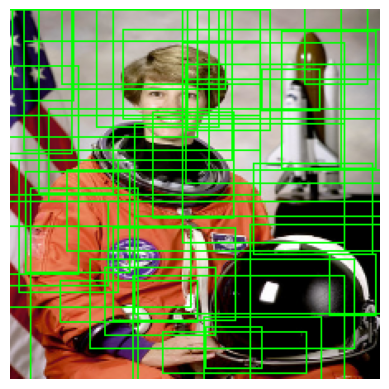

In [ ]:
# ================= KONVERSI OUTPUT =================
proposals_np = proposals[0].detach().cpu().numpy()
# - proposals[0] → ambil hasil dari batch pertama
# - detach() → lepas dari graph PyTorch (tidak perlu gradient)
# - cpu() → pindahkan ke CPU (kalau sebelumnya di GPU)
# - numpy() → ubah ke format numpy biar mudah diproses

# ================= GAMBAR BOUNDING BOX =================
image_with_boxes = image.copy()
# salin gambar agar tidak merusak gambar asli

for (x_min, y_min, x_max, y_max) in proposals_np[:100]:
    # ambil 100 proposal teratas (biar tidak terlalu penuh)

    x_min, y_min, x_max, y_max = int(x_min), int(y_min), int(x_max), int(y_max)
    # ubah ke integer (koordinat pixel harus bilangan bulat)

    cv2.rectangle(
        image_with_boxes,
        (x_min, y_min),     # titik kiri atas
        (x_max, y_max),     # titik kanan bawah
        (0, 255, 0),        # warna hijau
        1                   # ketebalan garis
    )

# ================= TAMPILKAN HASIL =================
imshow(image_with_boxes, isBGR=False)
# tampilkan hasil (RGB, jadi isBGR=False)

_____
<br>
<br>
<br>
<br>

## Source
- https://www.linkedin.com/pulse/basic-building-blocks-k-means-clustering-algorithms-hemant-thapa-jnide/